In [1]:
# ============================================================
# HAMI WORKAROUND:
# DISABLE TRANSFORMERS ALLOCATOR WARMUP
# ============================================================

import gc
import torch
import transformers.modeling_utils as modeling_utils

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


# Save the original function in case it is needed later.
_original_caching_allocator_warmup = (
    modeling_utils.caching_allocator_warmup
)


def _skip_caching_allocator_warmup(
    *args,
    **kwargs
):
    return None


modeling_utils.caching_allocator_warmup = (
    _skip_caching_allocator_warmup
)


print(
    "Transformers allocator warmup disabled."
)

free_memory, total_memory = (
    torch.cuda.mem_get_info()
)

print(
    f"CUDA free : "
    f"{free_memory / 1024**3:.2f} GB"
)

print(
    f"CUDA total: "
    f"{total_memory / 1024**3:.2f} GB"
)

[HAMI-core Msg(328:139749176085824:libvgpu.c:839)]: Initializing.....
[HAMI-core Msg(328:139749176085824:libvgpu.c:855)]: Initialized


Transformers allocator warmup disabled.
CUDA free : 15.59 GB
CUDA total: 16.00 GB


In [2]:
# ============================================================
# MISTRAL CLASSIFICATION EVALUATION
# PROJECT SETUP
# ============================================================

from pathlib import Path

import gc
import json
import random
import time

import numpy as np
import pandas as pd
import torch


# ============================================================
# PROJECT PATHS
# ============================================================

PROJECT_ROOT = Path(
    "/home/jovyan/project work/data_analyssis"
)

FINE_TUNING_DIR = (
    PROJECT_ROOT
    / "fine tuning"
)

CLASSIFIER_DIR = (
    PROJECT_ROOT
    / "classifier"
)


# ============================================================
# MODEL PATHS
# ============================================================

BASE_MODEL_ID = (
    "mistralai/Mistral-7B-Instruct-v0.2"
)

ADAPTER_DIR = (
    FINE_TUNING_DIR
    / "outputs"
    / "mistral_qlora"
    / "final_adapter"
)


# ============================================================
# RUHSOLD DATA PATHS
# ============================================================

TRAIN_PATH = (
    PROJECT_ROOT
    / "RUHSOLD_train.tsv"
)

VAL_PATH = (
    PROJECT_ROOT
    / "RUHSOLD_validation.tsv"
)

TEST_PATH = (
    PROJECT_ROOT
    / "RUHSOLD_test.tsv"
)


# ============================================================
# OUTPUT PATHS
# ============================================================

MISTRAL_CLASSIFICATION_DIR = (
    FINE_TUNING_DIR
    / "outputs"
    / "mistral_classification"
)

MISTRAL_CLASSIFICATION_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ============================================================
# BASIC CHECKS
# ============================================================

print(
    "Base model:",
    BASE_MODEL_ID
)

print(
    "Adapter exists:",
    ADAPTER_DIR.exists()
)

print(
    "Train exists:",
    TRAIN_PATH.exists()
)

print(
    "Validation exists:",
    VAL_PATH.exists()
)

print(
    "Test exists:",
    TEST_PATH.exists()
)

print(
    "Output directory:",
    MISTRAL_CLASSIFICATION_DIR
)

Base model: mistralai/Mistral-7B-Instruct-v0.2
Adapter exists: True
Train exists: True
Validation exists: True
Test exists: True
Output directory: /home/jovyan/project work/data_analyssis/fine tuning/outputs/mistral_classification


In [3]:
# ============================================================
# LOAD RUHSOLD SPLITS
# ============================================================

train_df = pd.read_csv(
    TRAIN_PATH,
    sep="\t",
    names=[
        "tweet",
        "label",
    ],
)

val_df = pd.read_csv(
    VAL_PATH,
    sep="\t",
    names=[
        "tweet",
        "label",
    ],
)

test_df = pd.read_csv(
    TEST_PATH,
    sep="\t",
    names=[
        "tweet",
        "label",
    ],
)


print(
    "Training samples:",
    len(train_df)
)

print(
    "Validation samples:",
    len(val_df)
)

print(
    "Test samples:",
    len(test_df)
)


print(
    "\nValidation class distribution:"
)

display(
    val_df[
        "label"
    ]
    .value_counts()
    .sort_index()
    .rename_axis("label")
    .reset_index(name="count")
)

Training samples: 6408
Validation samples: 801
Test samples: 2003

Validation class distribution:


,label,count
0,0,192
1,1,428
2,2,63
3,3,67
4,4,51


In [4]:
# ============================================================
# RUHSOLD LABEL DEFINITIONS
# ============================================================

LABEL_CONFIG = {

    0: {
        "name":
            "Abusive/Offensive",

        "definition":
            (
                "A post containing insults, personal attacks, "
                "humiliation, offensive language, or abuse, "
                "without primarily targeting religion or gender "
                "and without being primarily classified as profanity."
            ),
    },

    1: {
        "name":
            "Normal",

        "definition":
            (
                "A neutral, ordinary, non-abusive post that does not "
                "contain hate speech, targeted abuse, or profanity."
            ),
    },

    2: {
        "name":
            "Religious Hate",

        "definition":
            (
                "A hateful, abusive, insulting, or discriminatory post "
                "whose primary target is a religion, religious group, "
                "religious identity, sect, or religious affiliation."
            ),
    },

    3: {
        "name":
            "Sexism",

        "definition":
            (
                "A hateful, abusive, insulting, discriminatory, or "
                "derogatory post primarily targeting a person or group "
                "on the basis of gender or using explicitly gender-based "
                "degradation."
            ),
    },

    4: {
        "name":
            "Profane",

        "definition":
            (
                "A post whose primary characteristic is profanity, "
                "vulgarity, obscene language, or swearing rather than "
                "targeted religious hate, sexism, or a general personal attack."
            ),
    },
}


id2label = {
    class_id:
        config["name"]
    for class_id, config
    in LABEL_CONFIG.items()
}

label2id = {
    label:
        class_id
    for class_id, label
    in id2label.items()
}


print(
    "RUHSOLD label definitions loaded:"
)

for class_id, config in (
    LABEL_CONFIG.items()
):

    print(
        f"{class_id}: "
        f'{config["name"]}'
    )

RUHSOLD label definitions loaded:
0: Abusive/Offensive
1: Normal
2: Religious Hate
3: Sexism
4: Profane


In [5]:
# ============================================================
# MISTRAL CLASSIFICATION
# LOAD TOKENIZER
# ============================================================

from transformers import AutoTokenizer


tokenizer = AutoTokenizer.from_pretrained(
    BASE_MODEL_ID
)


# Mistral does not define a dedicated padding token.
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


tokenizer.padding_side = "left"


print(
    "Tokenizer loaded:",
    BASE_MODEL_ID
)

print(
    "Pad token:",
    tokenizer.pad_token
)

print(
    "EOS token:",
    tokenizer.eos_token
)

Tokenizer loaded: mistralai/Mistral-7B-Instruct-v0.2
Pad token: </s>
EOS token: </s>


In [6]:
# ============================================================
# CHECK GPU MEMORY BEFORE MODEL LOADING
# ============================================================

import gc
import torch


gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


print(
    "CUDA available:",
    torch.cuda.is_available()
)


if torch.cuda.is_available():

    free_memory, total_memory = (
        torch.cuda.mem_get_info()
    )

    print(
        f"CUDA free : "
        f"{free_memory / 1024**3:.2f} GB"
    )

    print(
        f"CUDA total: "
        f"{total_memory / 1024**3:.2f} GB"
    )

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

CUDA available: True
CUDA free : 15.59 GB
CUDA total: 16.00 GB
GPU: NVIDIA A100 80GB PCIe


In [7]:
# ============================================================
# LOAD BASE MISTRAL IN 4-BIT
# ============================================================

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
)

tokenizer = AutoTokenizer.from_pretrained(
    BASE_MODEL_ID
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)


base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    quantization_config=quantization_config,
    device_map="auto",
    dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
)

base_model.config.use_cache = False

print("Base Mistral loaded successfully.")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Base Mistral loaded successfully.


In [15]:
# ============================================================
# LOAD FINE-TUNED QLORA ADAPTER
# ============================================================

from peft import PeftModel

finetuned_model = PeftModel.from_pretrained(
    base_model,
    ADAPTER_DIR,
    is_trainable=False,
    autocast_adapter_dtype=False,
    low_cpu_mem_usage=True,
)

finetuned_model.eval()

print("Fine-tuned Mistral loaded successfully.")

/home/jovyan/.local/lib/python3.12/site-packages/peft/tuners/tuners_utils.py:305: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Fine-tuned Mistral loaded successfully.


In [16]:
print(
    "finetuned_model exists:",
    "finetuned_model" in globals()
)

print(
    "Training mode:",
    finetuned_model.training
)

print(
    "Adapters:",
    finetuned_model.peft_config.keys()
)

finetuned_model exists: True
Training mode: False
Adapters: dict_keys(['default'])


In [17]:
# ============================================================
# CHECK WHETHER MODEL IS DOUBLE-WRAPPED WITH PEFT
# ============================================================

from peft import PeftModel

print("base_model type:")
print(type(base_model))

print("\nfinetuned_model type:")
print(type(finetuned_model))

print(
    "\nbase_model has peft_config:",
    hasattr(base_model, "peft_config")
)

print(
    "finetuned_model has peft_config:",
    hasattr(finetuned_model, "peft_config")
)

print(
    "\nfinetuned_model adapters:",
    list(finetuned_model.peft_config.keys())
)

base_model type:
<class 'transformers.models.mistral.modeling_mistral.MistralForCausalLM'>

finetuned_model type:
<class 'peft.peft_model.PeftModelForCausalLM'>

base_model has peft_config: True
finetuned_model has peft_config: True

finetuned_model adapters: ['default']


In [18]:
print(
    "Active adapters:",
    finetuned_model.active_adapters
)

Active adapters: ['default']


In [9]:
# ============================================================
# CLEAN FAILED ADAPTER LOAD
# ============================================================

import gc
import torch

if "finetuned_model" in globals():
    del finetuned_model

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

free_memory, total_memory = torch.cuda.mem_get_info()

print(
    f"CUDA free : {free_memory / 1024**3:.2f} GB"
)

print(
    f"CUDA total: {total_memory / 1024**3:.2f} GB"
)

CUDA free : 11.67 GB
CUDA total: 16.00 GB


In [10]:
# ============================================================
# MISTRAL ZERO-SHOT CLASSIFICATION PROMPT
# ============================================================

def build_classification_messages(
    tweet
):
    """
    Build a zero-shot RUHSOLD classification prompt.

    The model must return only one class ID:
    0, 1, 2, 3, or 4.
    """

    system_message = """
You are a classifier for the RUHSOLD Roman Urdu hate speech dataset.

Classify the given Roman Urdu social-media post into exactly ONE of the following five classes.

0 = Abusive/Offensive
Insults, personal attacks, humiliation, or offensive language that is not primarily based on religion or gender and is not primarily simple profanity.

1 = Normal
Neutral or ordinary non-abusive language without hate speech, targeted abuse, or profanity.

2 = Religious Hate
Hateful, abusive, insulting, or discriminatory language primarily targeting a religion, religious group, sect, religious identity, or religious affiliation.

3 = Sexism
Hateful, abusive, insulting, discriminatory, or derogatory language primarily targeting a person or group based on gender, or containing gender-based degradation.

4 = Profane
Language whose main characteristic is profanity, vulgarity, obscene language, or swearing, without the primary target being religion or gender.

Important decision rule:
If the post primarily targets religion, choose Religious Hate.
If the post primarily targets gender, choose Sexism.
If it is mainly general abuse or a personal attack, choose Abusive/Offensive.
If it is mainly profanity without a more specific religious or gender target, choose Profane.
If it is non-abusive, choose Normal.

Return ONLY the class ID:
0, 1, 2, 3, or 4.

Do not explain your answer.
"""

    user_message = (
        f"Post:\n{str(tweet)}"
    )

    return [
        {
            "role": "system",
            "content": system_message.strip(),
        },
        {
            "role": "user",
            "content": user_message,
        },
    ]


print(
    "Zero-shot classification prompt loaded."
)

Zero-shot classification prompt loaded.


In [19]:
# ============================================================
# MISTRAL ZERO-SHOT CLASSIFICATION FUNCTION
# ============================================================

import re
import torch


@torch.inference_mode()
def classify_one(
    tweet,
    max_new_tokens=5,
):

    messages = build_classification_messages(
        tweet
    )

    prompt_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(
        prompt_text,
        return_tensors="pt",
    )

    # --------------------------------------------------------
    # Correct device for automatically dispatched models
    # --------------------------------------------------------

    input_device = (
        finetuned_model
        .get_input_embeddings()
        .weight
        .device
    )

    inputs = {
        key: value.to(input_device)
        for key, value
        in inputs.items()
    }

    # --------------------------------------------------------
    # Deterministic prediction
    # --------------------------------------------------------

    outputs = finetuned_model.generate(
        **inputs,

        do_sample=False,

        max_new_tokens=max_new_tokens,

        use_cache=False,

        pad_token_id=tokenizer.eos_token_id,

        eos_token_id=tokenizer.eos_token_id,
    )

    generated_tokens = outputs[
        0,
        inputs["input_ids"].shape[1]:
    ]

    response = (
        tokenizer.decode(
            generated_tokens,
            skip_special_tokens=True,
        )
        .strip()
    )

    # --------------------------------------------------------
    # Extract class ID
    # --------------------------------------------------------

    match = re.search(
        r"\b([0-4])\b",
        response
    )

    predicted_class_id = (
        int(match.group(1))
        if match
        else None
    )

    return {
        "prediction": predicted_class_id,
        "raw_response": response,
    }


print(
    "Mistral classification function loaded."
)

Mistral classification function loaded.


In [20]:
# ============================================================
# 10-SAMPLE VALIDATION SANITY TEST
# ============================================================

sanity_df = (
    val_df
    .sample(
        n=10,
        random_state=42
    )
    .copy()
    .reset_index(drop=True)
)


sanity_results = []


for index, row in sanity_df.iterrows():

    result = classify_one(
        row["tweet"]
    )

    predicted_id = result[
        "prediction"
    ]

    sanity_results.append({

        "tweet":
            row["tweet"],

        "true_label":
            int(
                row["label"]
            ),

        "true_class":
            id2label[
                int(
                    row["label"]
                )
            ],

        "predicted_label":
            predicted_id,

        "predicted_class":
            (
                id2label[
                    predicted_id
                ]
                if predicted_id is not None
                else "PARSE FAILURE"
            ),

        "raw_response":
            result[
                "raw_response"
            ],
    })


sanity_results_df = pd.DataFrame(
    sanity_results
)


display(
    sanity_results_df
)

,tweet,true_label,true_class,predicted_label,predicted_class,raw_response
0,tu apni maa bahan ko halala se to bacha le,2,Religious Hate,0,Abusive/Offensive,0
1,oh sad..ho jani chahiye thi..🤐,1,Normal,1,Normal,1
2,no bhaiyya i was not waiting for your mistak...,1,Normal,1,Normal,1
3,"there is no shia , sunni , christian , ahmedi ...",1,Normal,1,Normal,1
4,abe oo randi ... sale jab police pe or army pe...,3,Sexism,0,Abusive/Offensive,0
5,ye b hai 😂😂,1,Normal,1,Normal,1
6,mai abhi kisi ka ghr b bsana😛,1,Normal,1,Normal,1
7,photo shop acha kia hai begerat bete baubloo b...,0,Abusive/Offensive,1,Normal,1
8,🖐ha aise logon pe shayad ye marna bhool chuke...,2,Religious Hate,2,Religious Hate,2
9,rt : man why’s the tims line on campus always ...,0,Abusive/Offensive,1,Normal,1


In [21]:
# ============================================================
# FULL MISTRAL VALIDATION CLASSIFICATION
# ============================================================

from tqdm.auto import tqdm

validation_records = []


for index, row in tqdm(
    val_df.iterrows(),
    total=len(val_df),
    desc="Mistral validation classification"
):

    result = classify_one(
        row["tweet"]
    )

    predicted_id = result[
        "prediction"
    ]

    validation_records.append({

        "index":
            index,

        "tweet":
            row["tweet"],

        "true_label":
            int(
                row["label"]
            ),

        "predicted_label":
            predicted_id,

        "raw_response":
            result[
                "raw_response"
            ],
    })


mistral_val_predictions_df = pd.DataFrame(
    validation_records
)


print(
    "Validation predictions completed:",
    len(mistral_val_predictions_df)
)

print(
    "Parse failures:",
    mistral_val_predictions_df[
        "predicted_label"
    ]
    .isna()
    .sum()
)

Mistral validation classification:   0%|          | 0/801 [00:00<?, ?it/s]

Validation predictions completed: 801
Parse failures: 1


In [22]:
# ============================================================
# SAVE RAW VALIDATION PREDICTIONS
# ============================================================

MISTRAL_VAL_PREDICTIONS_PATH = (
    MISTRAL_CLASSIFICATION_DIR
    / "mistral_zero_shot_validation_predictions.csv"
)


mistral_val_predictions_df.to_csv(
    MISTRAL_VAL_PREDICTIONS_PATH,
    index=False,
    encoding="utf-8",
)


print(
    "Saved to:"
)

print(
    MISTRAL_VAL_PREDICTIONS_PATH
)

Saved to:
/home/jovyan/project work/data_analyssis/fine tuning/outputs/mistral_classification/mistral_zero_shot_validation_predictions.csv


In [23]:
# ============================================================
# MISTRAL VALIDATION METRICS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)


valid_predictions_df = (
    mistral_val_predictions_df[
        mistral_val_predictions_df[
            "predicted_label"
        ]
        .notna()
    ]
    .copy()
)


y_true = (
    valid_predictions_df[
        "true_label"
    ]
    .astype(int)
    .to_numpy()
)

y_pred = (
    valid_predictions_df[
        "predicted_label"
    ]
    .astype(int)
    .to_numpy()
)


accuracy = accuracy_score(
    y_true,
    y_pred
)


(
    macro_precision,
    macro_recall,
    macro_f1,
    _
) = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="macro",
    zero_division=0,
)


(
    weighted_precision,
    weighted_recall,
    weighted_f1,
    _
) = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0,
)


print("=" * 60)
print("MISTRAL ZERO-SHOT VALIDATION RESULTS")
print("=" * 60)

print(
    f"Accuracy        : {accuracy:.4f}"
)

print(
    f"Macro Precision : {macro_precision:.4f}"
)

print(
    f"Macro Recall    : {macro_recall:.4f}"
)

print(
    f"Macro F1        : {macro_f1:.4f}"
)

print(
    f"Weighted F1     : {weighted_f1:.4f}"
)

MISTRAL ZERO-SHOT VALIDATION RESULTS
Accuracy        : 0.6362
Macro Precision : 0.5319
Macro Recall    : 0.4156
Macro F1        : 0.4308
Weighted F1     : 0.5917


In [24]:
# ============================================================
# PER-CLASS VALIDATION PERFORMANCE
# ============================================================

report = classification_report(
    y_true,
    y_pred,
    labels=[0, 1, 2, 3, 4],
    target_names=[
        "Abusive/Offensive",
        "Normal",
        "Religious Hate",
        "Sexism",
        "Profane",
    ],
    output_dict=True,
    digits=4,
    zero_division=0,
)


report_df = pd.DataFrame(
    report
).transpose()


display(
    report_df
)

,precision,recall,f1-score,support
Abusive/Offensive,0.410596,0.322917,0.361516,192.00000
Normal,0.717352,0.939110,0.813387,427.00000
Religious Hate,0.500000,0.126984,0.202532,63.00000
Sexism,0.521739,0.179104,0.266667,67.00000
Profane,0.509804,0.509804,0.509804,51.00000
accuracy,0.636250,0.636250,0.636250,0.63625
macro avg,0.531898,0.415584,0.430781,800.00000
weighted avg,0.597001,0.636250,0.591692,800.00000


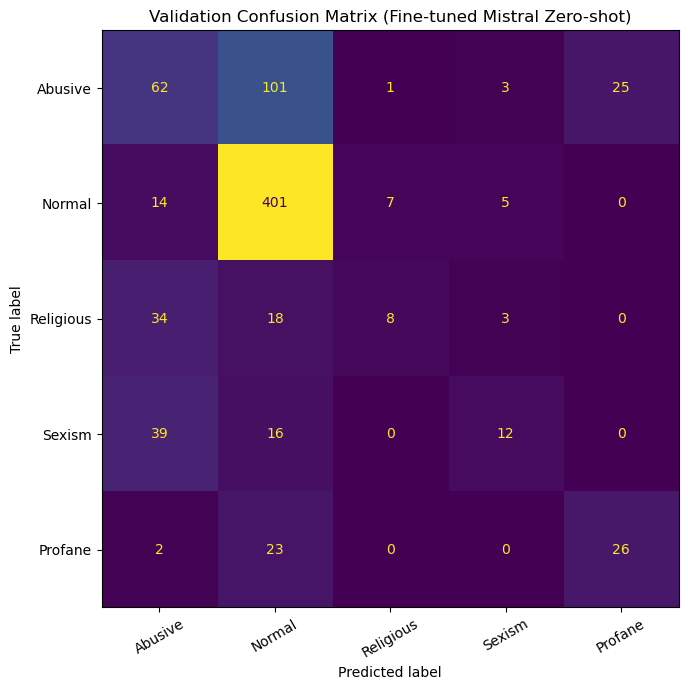


Confusion matrix:
[[ 62 101   1   3  25]
 [ 14 401   7   5   0]
 [ 34  18   8   3   0]
 [ 39  16   0  12   0]
 [  2  23   0   0  26]]


In [25]:
# ============================================================
# VALIDATION CONFUSION MATRIX
# ============================================================

import matplotlib.pyplot as plt

from sklearn.metrics import (
    ConfusionMatrixDisplay,
)


cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1, 2, 3, 4],
)


display_labels = [
    "Abusive",
    "Normal",
    "Religious",
    "Sexism",
    "Profane",
]


fig, ax = plt.subplots(
    figsize=(8, 7)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=display_labels,
)

disp.plot(
    values_format="d",
    ax=ax,
    colorbar=False,
)

plt.title(
    "Validation Confusion Matrix "
    "(Fine-tuned Mistral Zero-shot)"
)

plt.xticks(
    rotation=30
)

plt.tight_layout()

plt.show()


print(
    "\nConfusion matrix:"
)

print(
    cm
)

In [26]:
# ============================================================
# FINAL TEST EVALUATION
# FINE-TUNED MISTRAL ZERO-SHOT CLASSIFICATION
# ============================================================

from tqdm.auto import tqdm
import pandas as pd
import numpy as np
import time


print("=" * 70)
print("FINAL TEST - FINE-TUNED MISTRAL ZERO-SHOT")
print("=" * 70)

print(
    "Test samples:",
    len(test_df)
)

assert len(test_df) == 2003


# ============================================================
# RUN TEST PREDICTIONS
# ============================================================

test_records = []

start_time = time.time()


for index, row in tqdm(
    test_df.iterrows(),
    total=len(test_df),
    desc="Mistral test classification",
):

    result = classify_one(
        row["tweet"]
    )

    predicted_id = result[
        "prediction"
    ]

    test_records.append({

        "index":
            index,

        "tweet":
            row["tweet"],

        "true_label":
            int(
                row["label"]
            ),

        "predicted_label":
            predicted_id,

        "raw_response":
            result[
                "raw_response"
            ],
    })


mistral_test_predictions_df = pd.DataFrame(
    test_records
)


test_time_seconds = (
    time.time()
    - start_time
)


print(
    "\nTest predictions completed:",
    len(mistral_test_predictions_df)
)

print(
    "Parse failures:",
    mistral_test_predictions_df[
        "predicted_label"
    ]
    .isna()
    .sum()
)

print(
    "Evaluation time:",
    f"{test_time_seconds / 60:.2f} minutes"
)

FINAL TEST - FINE-TUNED MISTRAL ZERO-SHOT
Test samples: 2003


Mistral test classification:   0%|          | 0/2003 [00:00<?, ?it/s]


Test predictions completed: 2003
Parse failures: 6
Evaluation time: 12.95 minutes


In [27]:
# ============================================================
# SAVE FINAL MISTRAL TEST PREDICTIONS
# ============================================================

MISTRAL_TEST_PREDICTIONS_PATH = (
    MISTRAL_CLASSIFICATION_DIR
    / "mistral_zero_shot_test_predictions.csv"
)


mistral_test_predictions_df.to_csv(
    MISTRAL_TEST_PREDICTIONS_PATH,
    index=False,
    encoding="utf-8",
)


print(
    "Saved final Mistral test predictions to:"
)

print(
    MISTRAL_TEST_PREDICTIONS_PATH
)

Saved final Mistral test predictions to:
/home/jovyan/project work/data_analyssis/fine tuning/outputs/mistral_classification/mistral_zero_shot_test_predictions.csv


In [28]:
# ============================================================
# FINAL MISTRAL TEST METRICS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)


# ------------------------------------------------------------
# Count parse failures
# ------------------------------------------------------------

parse_failures = int(
    mistral_test_predictions_df[
        "predicted_label"
    ]
    .isna()
    .sum()
)

parse_failure_rate = (
    parse_failures
    / len(
        mistral_test_predictions_df
    )
)


# ------------------------------------------------------------
# Preserve ALL 2003 test examples
#
# Parse failure = -1 = incorrect prediction
# ------------------------------------------------------------

y_true_test = (
    mistral_test_predictions_df[
        "true_label"
    ]
    .astype(int)
    .to_numpy()
)


y_pred_test = (
    mistral_test_predictions_df[
        "predicted_label"
    ]
    .fillna(-1)
    .astype(int)
    .to_numpy()
)


# ============================================================
# OVERALL METRICS
# ============================================================

test_accuracy = accuracy_score(
    y_true_test,
    y_pred_test
)


(
    test_macro_precision,
    test_macro_recall,
    test_macro_f1,
    _
) = precision_recall_fscore_support(
    y_true_test,
    y_pred_test,
    labels=[
        0,
        1,
        2,
        3,
        4,
    ],
    average="macro",
    zero_division=0,
)


(
    test_weighted_precision,
    test_weighted_recall,
    test_weighted_f1,
    _
) = precision_recall_fscore_support(
    y_true_test,
    y_pred_test,
    labels=[
        0,
        1,
        2,
        3,
        4,
    ],
    average="weighted",
    zero_division=0,
)


print("\n")
print("=" * 70)
print("FINAL MISTRAL ZERO-SHOT TEST RESULTS")
print("=" * 70)

print(
    f"Accuracy        : "
    f"{test_accuracy:.4f}"
)

print(
    f"Macro Precision : "
    f"{test_macro_precision:.4f}"
)

print(
    f"Macro Recall    : "
    f"{test_macro_recall:.4f}"
)

print(
    f"Macro F1        : "
    f"{test_macro_f1:.4f}"
)

print(
    f"Weighted F1     : "
    f"{test_weighted_f1:.4f}"
)

print(
    f"Parse failures  : "
    f"{parse_failures}/{len(test_df)} "
    f"({parse_failure_rate:.2%})"
)



FINAL MISTRAL ZERO-SHOT TEST RESULTS
Accuracy        : 0.6331
Macro Precision : 0.5494
Macro Recall    : 0.4017
Macro F1        : 0.4340
Weighted F1     : 0.5930
Parse failures  : 6/2003 (0.30%)


In [29]:
# ============================================================
# FINAL MISTRAL TEST PER-CLASS PERFORMANCE
# ============================================================

test_report = classification_report(
    y_true_test,
    y_pred_test,
    labels=[
        0,
        1,
        2,
        3,
        4,
    ],
    target_names=[
        "Abusive/Offensive",
        "Normal",
        "Religious Hate",
        "Sexism",
        "Profane",
    ],
    output_dict=True,
    digits=4,
    zero_division=0,
)


mistral_test_report_df = (
    pd.DataFrame(
        test_report
    )
    .transpose()
)


display(
    mistral_test_report_df
)

,precision,recall,f1-score,support
Abusive/Offensive,0.433243,0.330561,0.375000,481.0
Normal,0.703808,0.932710,0.802251,1070.0
Religious Hate,0.604651,0.166667,0.261307,156.0
Sexism,0.541176,0.273810,0.363636,168.0
Profane,0.464286,0.304688,0.367925,128.0
micro avg,0.634952,0.633050,0.634000,2003.0
macro avg,0.549433,0.401687,0.434024,2003.0
weighted avg,0.602165,0.633050,0.592977,2003.0


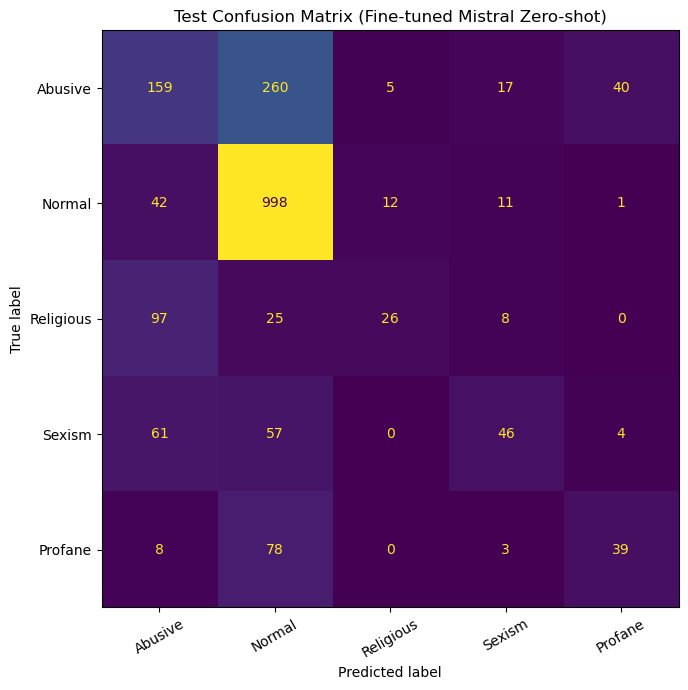


Confusion matrix:
[[159 260   5  17  40]
 [ 42 998  12  11   1]
 [ 97  25  26   8   0]
 [ 61  57   0  46   4]
 [  8  78   0   3  39]]


In [30]:
# ============================================================
# FINAL MISTRAL TEST CONFUSION MATRIX
# ============================================================

import matplotlib.pyplot as plt

from sklearn.metrics import (
    ConfusionMatrixDisplay,
)


mistral_test_cm = confusion_matrix(
    y_true_test,
    y_pred_test,
    labels=[
        0,
        1,
        2,
        3,
        4,
    ],
)


display_labels = [
    "Abusive",
    "Normal",
    "Religious",
    "Sexism",
    "Profane",
]


fig, ax = plt.subplots(
    figsize=(8, 7)
)


disp = ConfusionMatrixDisplay(
    confusion_matrix=(
        mistral_test_cm
    ),
    display_labels=(
        display_labels
    ),
)


disp.plot(
    values_format="d",
    ax=ax,
    colorbar=False,
)


plt.title(
    "Test Confusion Matrix "
    "(Fine-tuned Mistral Zero-shot)"
)

plt.xticks(
    rotation=30
)

plt.tight_layout()

plt.show()


print(
    "\nConfusion matrix:"
)

print(
    mistral_test_cm
)

In [31]:
# ============================================================
# SAVE FINAL MISTRAL TEST SUMMARY
# ============================================================

mistral_test_summary_df = pd.DataFrame(
    [
        {
            "model":
                "Fine-tuned Mistral Zero-shot",

            "test_samples":
                len(test_df),

            "accuracy":
                test_accuracy,

            "macro_precision":
                test_macro_precision,

            "macro_recall":
                test_macro_recall,

            "macro_f1":
                test_macro_f1,

            "weighted_precision":
                test_weighted_precision,

            "weighted_recall":
                test_weighted_recall,

            "weighted_f1":
                test_weighted_f1,

            "parse_failures":
                parse_failures,

            "parse_failure_rate":
                parse_failure_rate,

            "evaluation_time_minutes":
                test_time_seconds / 60,
        }
    ]
)


mistral_test_summary_df.to_csv(
    MISTRAL_CLASSIFICATION_DIR
    / "mistral_zero_shot_test_summary.csv",
    index=False,
)


mistral_test_report_df.to_csv(
    MISTRAL_CLASSIFICATION_DIR
    / "mistral_zero_shot_test_per_class.csv"
)


display(
    mistral_test_summary_df.round(4)
)


print(
    "\nFinal Mistral test results saved."
)

,model,test_samples,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,parse_failures,parse_failure_rate,evaluation_time_minutes
0,Fine-tuned Mistral Zero-shot,2003,0.6331,0.5494,0.4017,0.434,0.6022,0.6331,0.593,6,0.003,12.9502



Final Mistral test results saved.
